# خوارزمية FAST لاكتشاف الزوايا:

### الهدف 
** في هذا الفصل : **
* سنفهم اسس خوارزمية FAST .

* سنوجد الزوايا باستخدام توابع OpenCV لخوارزمية FAST .


### النظرية :
رأينا العديد من مكتشفات الخصائص والعديد منهم جيدين. ولكن حينتما يتعلق الامر بتطبيقات الزمن الحقيقي , فسرعتهم قد لا تكفي , واحد الامثلة هو التحديد الاني للموضع والتخطيط SLAM  للروبوتات التي لديها قدرات حوسبة منخفضة .

وكحل لهذا , تم تطوير خوارزمية FAST  ( الخصائص من الاختبارات المسرعة للقطعة ) وذلك ضمن ورقة باسم "تعليم الالة لاكتشاف الزوايا عالي السرعة " في 2006  (لاحقاً تمت مراجعتها في 2010 ) والتالي هو ملخص لاساسيات تلك الورقة وكل الاشكال هنا تابعة لها.


<img src="../../images/p175.jpg">

### اكتشاف الخصائص باستخدام FAST :

1. اختر البكسل $p$  في الصورة والذي علينا تحديد هل هو نقطة  زاوية ام لا , ولنفرض شدته : $I_p$ .

2. اختر قيمة العتبة المناسبة $t$ .

3. خذ دائرة من 16 بكسل حول البكسل المختبر . (انظر للصورة أعلاه ).

4. والان فالبكسل p هو زاوية اذا وجدت مجموعة من n  بكسل مرتبط بدائرة , ( من 16 بكسل ) وسطوعها أعلى من $ I_p + t $  أو كلها اغمق من  $ I_p t $ . و n  تكون 12 عادة .

5. وتم انشاء ** اختبار عالي السرعة ** لتنحية عدد كبير من النقاط اللا زاوية . وهذا الاختبار يمتحن فقط البكسلات الاربعة عند 1 , 9 , 5  و 13 (اولا 1 و 9 تختبر  اذا ما كانت عالية السطوع او منخفضة . وعندها نختبر ال 5 و 13 .)  اذا كانت p  زاوية , عندها ثلاثة على الاقل منهم يجب ان تحقق شرط العتبات , والا فان p لا يمكن ان تكون حافة . معيار المقطع الكامل يمكن تطبيقه للمرشح الممر  باختبار كل البكسلات في الدائرة . وهذا المكتشف بحد ذاته يمتلك اداء عالياً ولكن, ولكن هناك عدد من نقاط الضعف :



* لا يرفض العدد نفسه من النقاط من اجل n < 12.

* اختيار البكسلات ليس امثلياً لان فعاليته تعتمد على ترتيب المتطلبات والتوزع لمظاهر الزوايا .

* يتم رمي نتائج الاختبارات عالية السرعة 

* عدد من الخصائص يتم اكتشافها بجوار بعضها.

اول ثلاث نقاط تتحدد باستخدام تقنيات تعليم الالة , الاخيرة تحل باستخدام الانضغاط اللااعظمي.

### الملخص :
هذه الخوارزمية اسرع بعدة مرات من المشتقات السابقة ولكنها غير متحملة لمستويات عالية من الضجيج . وهذا يعتمد على العتبة .


### FAST  في OpenCV:

وهذا يطبق كما اي مكتشف خصائص في OpenCV  , حيث يمكنك تحديد العتبة , تطبيق الضغط اللااعظمي من عدمه , الجوار الواجب استخدامه.

وللجوار يمكن تمرير 3 اعلام :

`cv2.FAST_FEATURE_DETECTOR_TYPE_5_8,
cv2.FAST_FEATURE_DETECTOR_TYPE_7_12  cv2.FAST_FEATURE_DETECTOR_TYPE_9_16.`


والتالي مثال :


Threshold:  10
nonmaxSuppression:  True
Total Keypoints with nonmaxSuppression:  1013
Total Keypoints without nonmaxSuppression:  2489


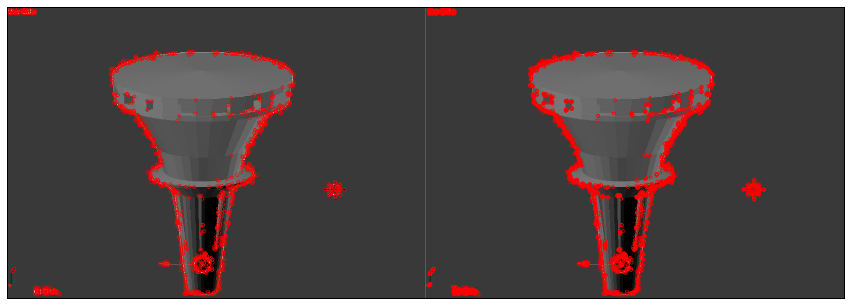

In [5]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

img = cv2.imread('wt.jpg',0)

# Initiate FAST object with default values
fast = cv2.FastFeatureDetector()

# find and draw the keypoints
kp = fast.detect(img,None)
img2 = cv2.drawKeypoints(img, kp, color=(255,0,0))

# Print all default params
print "Threshold: ", fast.getInt('threshold')
print "nonmaxSuppression: ", fast.getBool('nonmaxSuppression')
# print "neighborhood: ", fast.getInt('type')
print "Total Keypoints with nonmaxSuppression: ", len(kp)

# cv2.imwrite('fast_true.png',img2)

# Disable nonmaxSuppression
fast.setBool('nonmaxSuppression',0)
kp = fast.detect(img,None)

print "Total Keypoints without nonmaxSuppression: ", len(kp)

img3 = cv2.drawKeypoints(img, kp, color=(255,0,0))

# cv2.imwrite('fast_false.png',img3)

res = np.hstack([img2 , img3])

plt.figure(figsize = (15,10))
plt.imshow(res)
plt.xticks([])
plt.yticks([])
plt.show()

# راقب النتائج,  الصورة الاولى مع انضغاط لا اعظمي والثانية بدونه.

### مراجع اضافية :

1. تعليم الالة لاكتشاف زوايا عالي السرعة .

2. اسرع وافضل : مقاربة تعليم آلة لاكتشاف زوايا.


### تمارين

2016-00-29 13:38:02 